Saving breastcancer_data.csv to breastcancer_data (3).csv
Loaded file: breastcancer_data (3).csv
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280       

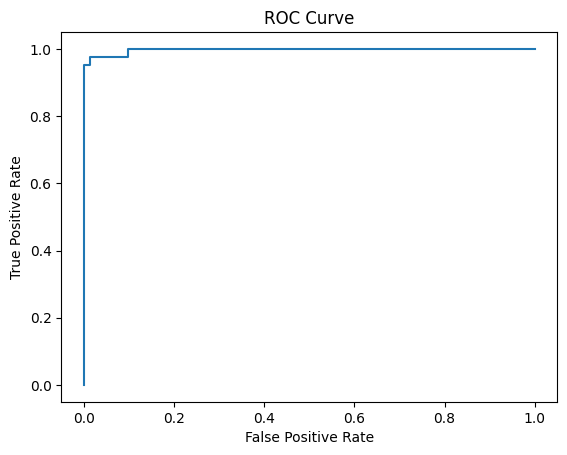


Custom Threshold = 0.3
Confusion Matrix:
 [[67  4]
 [ 1 42]]
Precision: 0.9130434782608695
Recall: 0.9767441860465116


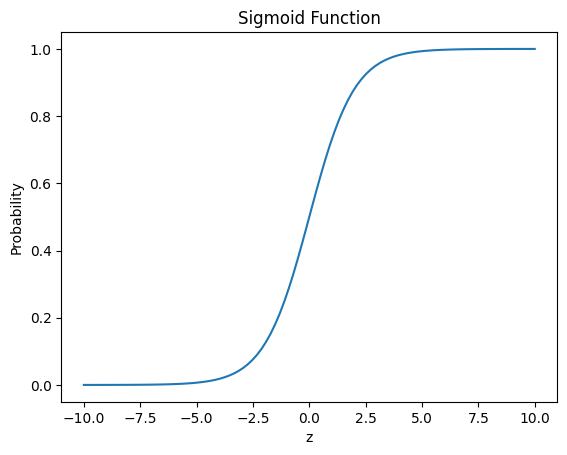

In [5]:
# ================================
# STEP 0: Upload File
# ================================
from google.colab import files
uploaded = files.upload()

import pandas as pd
import io

file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("Loaded file:", file_name)
print(df.head())


# ================================
# STEP 1: Data Cleaning
# ================================

# Drop useless column
if 'Unnamed: 32' in df.columns:
    df = df.drop(columns=['Unnamed: 32'])

# Drop ID column if present
if 'id' in df.columns:
    df = df.drop(columns=['id'])

# Convert target column
df['diagnosis'] = df['diagnosis'].map({'M':1, 'B':0})

# Separate features and target
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

# Handle NaN values (IMPORTANT FIX)
X = X.fillna(X.mean())

print("Any NaN left:", X.isnull().sum().sum())


# ================================
# STEP 2: Train-Test Split + Scaling
# ================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ================================
# STEP 3: Logistic Regression
# ================================
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


# ================================
# STEP 4: Evaluation
# ================================
from sklearn.metrics import confusion_matrix, precision_score, recall_score, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


# ================================
# STEP 5: ROC Curve
# ================================
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


# ================================
# STEP 6: Threshold Tuning
# ================================
threshold = 0.3
y_pred_custom = (y_prob >= threshold).astype(int)

print("\nCustom Threshold =", threshold)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_custom))
print("Precision:", precision_score(y_test, y_pred_custom))
print("Recall:", recall_score(y_test, y_pred_custom))


# ================================
# STEP 7: Sigmoid Function
# ================================
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 100)
sig = sigmoid(z)

plt.plot(z, sig)
plt.title("Sigmoid Function")
plt.xlabel("z")
plt.ylabel("Probability")
plt.show()